In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

raw_train_df = pd.read_csv("datasets/house-prices/train.csv")
raw_test_df = pd.read_csv("datasets/house-prices/test.csv")

raw_train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
raw_train_df.shape

(1460, 81)

In [3]:
numeric_features = raw_train_df.select_dtypes(include=["int64", "float64"]).columns
categorical_features = raw_train_df.select_dtypes(include=["object"]).columns

ids = raw_test_df["Id"]
numeric_features = numeric_features.drop("Id")

In [4]:
# Treating MSSubClass as a categorical feature instead of a numeric feature
categorical_features = categorical_features.union(["MSSubClass"])
numeric_features = numeric_features.drop("MSSubClass")

In [5]:
categorical_features

Index(['Alley', 'BldgType', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'BsmtQual', 'CentralAir', 'Condition1', 'Condition2',
       'Electrical', 'ExterCond', 'ExterQual', 'Exterior1st', 'Exterior2nd',
       'Fence', 'FireplaceQu', 'Foundation', 'Functional', 'GarageCond',
       'GarageFinish', 'GarageQual', 'GarageType', 'Heating', 'HeatingQC',
       'HouseStyle', 'KitchenQual', 'LandContour', 'LandSlope', 'LotConfig',
       'LotShape', 'MSSubClass', 'MSZoning', 'MasVnrType', 'MiscFeature',
       'Neighborhood', 'PavedDrive', 'PoolQC', 'RoofMatl', 'RoofStyle',
       'SaleCondition', 'SaleType', 'Street', 'Utilities'],
      dtype='object')

In [6]:
numeric_features

Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

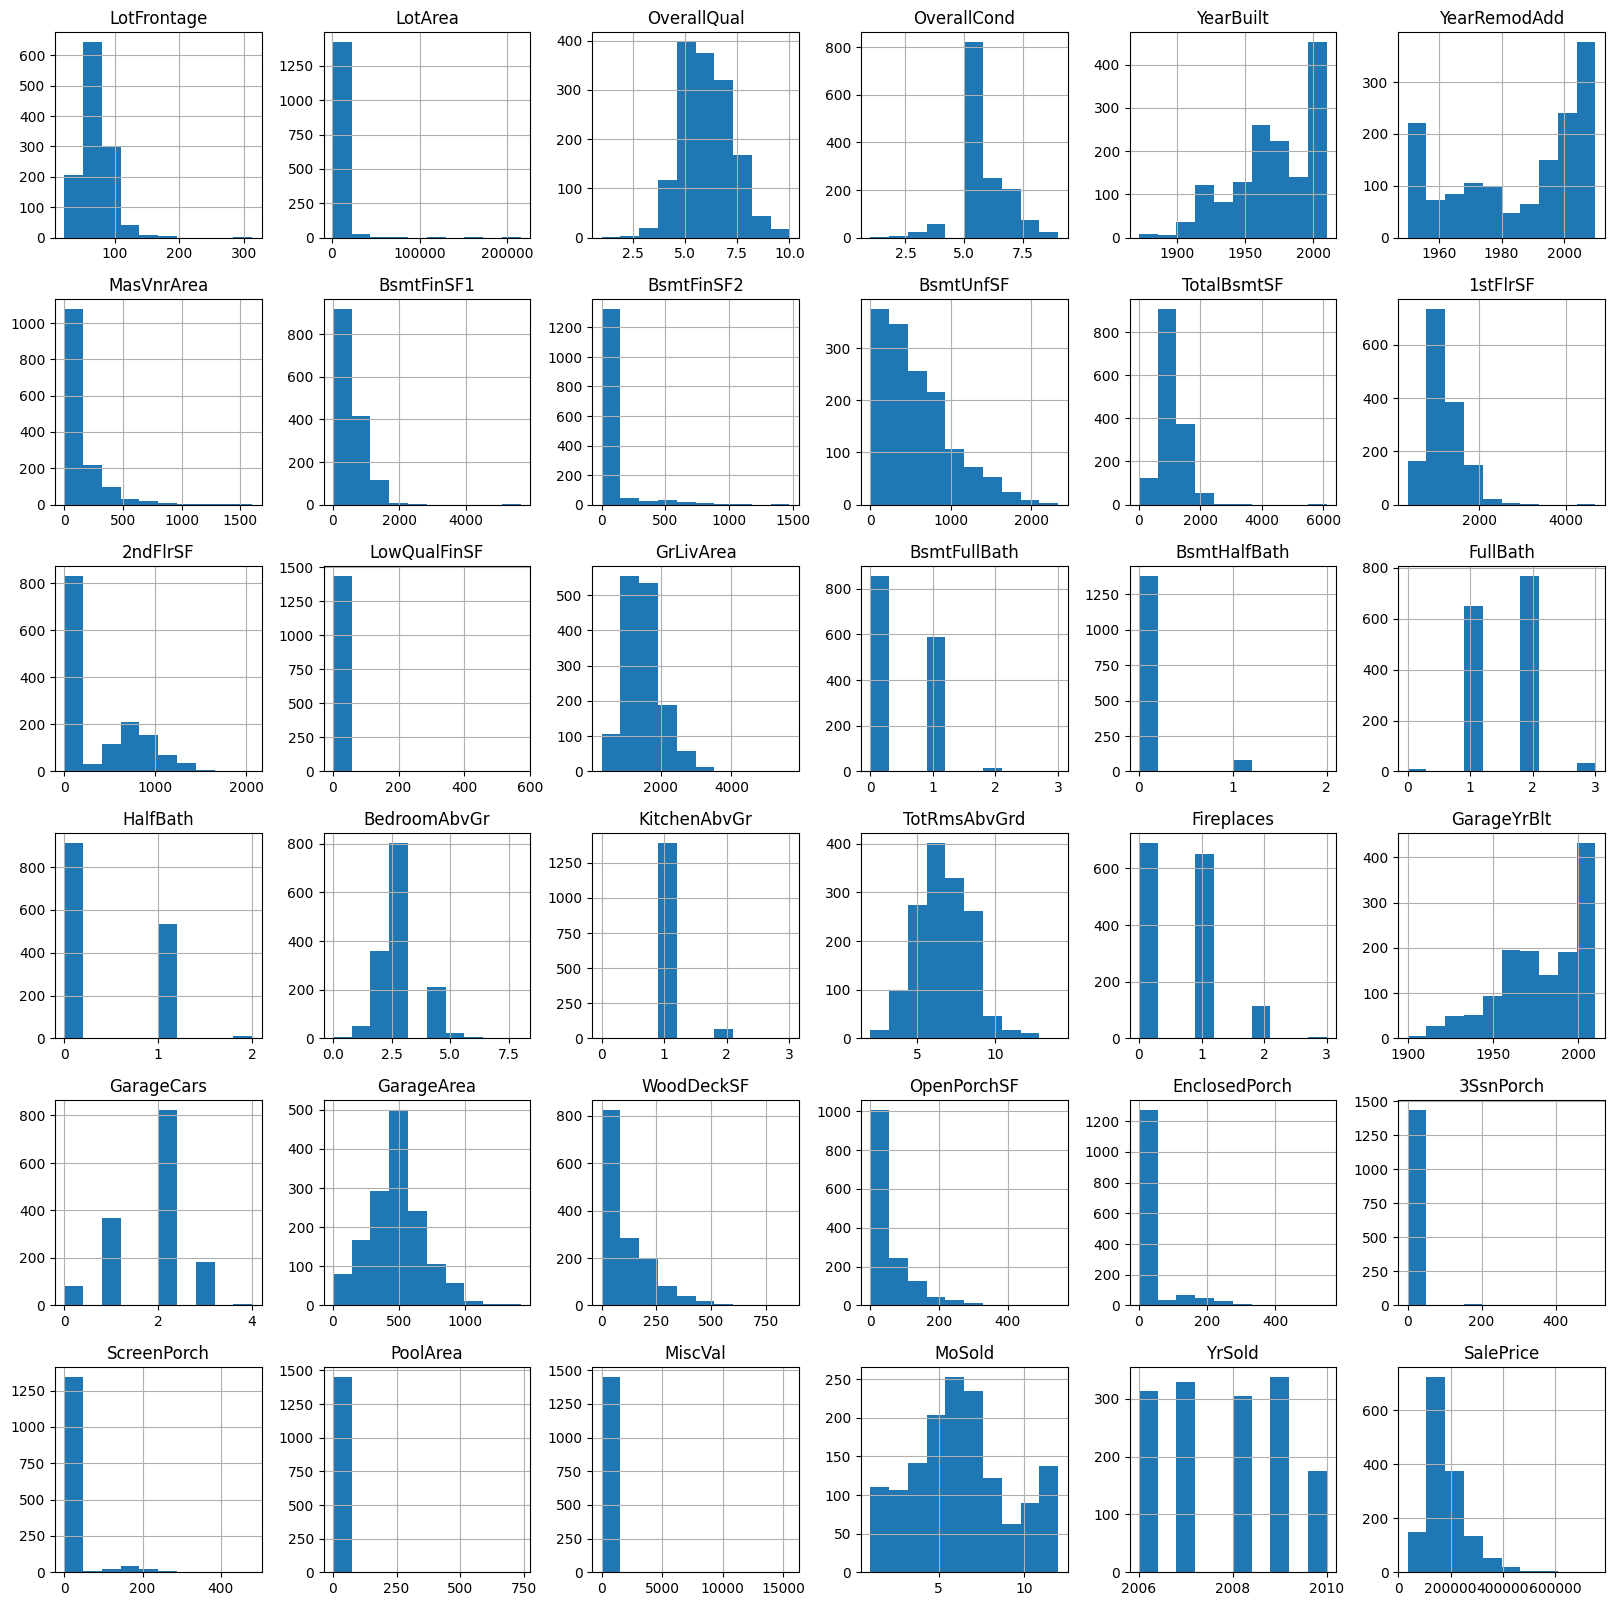

In [7]:
raw_train_df[numeric_features].hist(figsize=(20, 20))
plt.show()

In [8]:
raw_train_df[numeric_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 36 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   LotFrontage    1201 non-null   float64
 1   LotArea        1460 non-null   int64  
 2   OverallQual    1460 non-null   int64  
 3   OverallCond    1460 non-null   int64  
 4   YearBuilt      1460 non-null   int64  
 5   YearRemodAdd   1460 non-null   int64  
 6   MasVnrArea     1452 non-null   float64
 7   BsmtFinSF1     1460 non-null   int64  
 8   BsmtFinSF2     1460 non-null   int64  
 9   BsmtUnfSF      1460 non-null   int64  
 10  TotalBsmtSF    1460 non-null   int64  
 11  1stFlrSF       1460 non-null   int64  
 12  2ndFlrSF       1460 non-null   int64  
 13  LowQualFinSF   1460 non-null   int64  
 14  GrLivArea      1460 non-null   int64  
 15  BsmtFullBath   1460 non-null   int64  
 16  BsmtHalfBath   1460 non-null   int64  
 17  FullBath       1460 non-null   int64  
 18  HalfBath

In [9]:
raw_test_df[numeric_features.drop("SalePrice")].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 35 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   LotFrontage    1232 non-null   float64
 1   LotArea        1459 non-null   int64  
 2   OverallQual    1459 non-null   int64  
 3   OverallCond    1459 non-null   int64  
 4   YearBuilt      1459 non-null   int64  
 5   YearRemodAdd   1459 non-null   int64  
 6   MasVnrArea     1444 non-null   float64
 7   BsmtFinSF1     1458 non-null   float64
 8   BsmtFinSF2     1458 non-null   float64
 9   BsmtUnfSF      1458 non-null   float64
 10  TotalBsmtSF    1458 non-null   float64
 11  1stFlrSF       1459 non-null   int64  
 12  2ndFlrSF       1459 non-null   int64  
 13  LowQualFinSF   1459 non-null   int64  
 14  GrLivArea      1459 non-null   int64  
 15  BsmtFullBath   1457 non-null   float64
 16  BsmtHalfBath   1457 non-null   float64
 17  FullBath       1459 non-null   int64  
 18  HalfBath

In [10]:
# Impute median values for missing LotFrontage values
median_lot_frontage = raw_train_df["LotFrontage"].median()
raw_train_df["LotFrontage"] = raw_train_df["LotFrontage"].fillna(median_lot_frontage)
raw_test_df["LotFrontage"] = raw_test_df["LotFrontage"].fillna(median_lot_frontage)

# Impute median values for missing MasVnrArea values
median_mas_vnr_area = raw_train_df["MasVnrArea"].median()
raw_train_df["MasVnrArea"] = raw_train_df["MasVnrArea"].fillna(median_mas_vnr_area)
raw_test_df["MasVnrArea"] = raw_test_df["MasVnrArea"].fillna(median_mas_vnr_area)

# Impute median values for missing BsmtFinSF1 values
median_bsmt_fin_sf1 = raw_train_df["BsmtFinSF1"].median()
raw_train_df["BsmtFinSF1"] = raw_train_df["BsmtFinSF1"].fillna(median_bsmt_fin_sf1)
raw_test_df["BsmtFinSF1"] = raw_test_df["BsmtFinSF1"].fillna(median_bsmt_fin_sf1)

# Impute median values for missing BsmtFinSF2 values
median_bsmt_fin_sf2 = raw_train_df["BsmtFinSF2"].median()
raw_train_df["BsmtFinSF2"] = raw_train_df["BsmtFinSF2"].fillna(median_bsmt_fin_sf2)
raw_test_df["BsmtFinSF2"] = raw_test_df["BsmtFinSF2"].fillna(median_bsmt_fin_sf2)

# Impute median values for missing BsmtUnfSF values
median_bsmt_unf_sf = raw_train_df["BsmtUnfSF"].median()
raw_train_df["BsmtUnfSF"] = raw_train_df["BsmtUnfSF"].fillna(median_bsmt_unf_sf)
raw_test_df["BsmtUnfSF"] = raw_test_df["BsmtUnfSF"].fillna(median_bsmt_unf_sf)

# Impute median values for missing TotalBsmtSF values
median_total_bsmt_sf = raw_train_df["TotalBsmtSF"].median()
raw_train_df["TotalBsmtSF"] = raw_train_df["TotalBsmtSF"].fillna(median_total_bsmt_sf)
raw_test_df["TotalBsmtSF"] = raw_test_df["TotalBsmtSF"].fillna(median_total_bsmt_sf)

# Impute median values for missing BsmtFullBath values
median_bsmt_full_bath = raw_train_df["BsmtFullBath"].median()
raw_train_df["BsmtFullBath"] = raw_train_df["BsmtFullBath"].fillna(median_bsmt_full_bath)
raw_test_df["BsmtFullBath"] = raw_test_df["BsmtFullBath"].fillna(median_bsmt_full_bath)

# Impute median values for missing BsmtHalfBath values
median_bsmt_half_bath = raw_train_df["BsmtHalfBath"].median()
raw_train_df["BsmtHalfBath"] = raw_train_df["BsmtHalfBath"].fillna(median_bsmt_half_bath)
raw_test_df["BsmtHalfBath"] = raw_test_df["BsmtHalfBath"].fillna(median_bsmt_half_bath)

# Impute median values for missing GarageYrBlt values
median_garage_yr_blt = raw_train_df["GarageYrBlt"].median()
raw_train_df["GarageYrBlt"] = raw_train_df["GarageYrBlt"].fillna(median_garage_yr_blt)
raw_test_df["GarageYrBlt"] = raw_test_df["GarageYrBlt"].fillna(median_garage_yr_blt)

# Impute median values for missing GarageCars values
median_garage_cars = raw_train_df["GarageCars"].median()
raw_train_df["GarageCars"] = raw_train_df["GarageCars"].fillna(median_garage_cars)
raw_test_df["GarageCars"] = raw_test_df["GarageCars"].fillna(median_garage_cars)

# Impute median values for missing GarageArea values
median_garage_area = raw_train_df["GarageArea"].median()
raw_train_df["GarageArea"] = raw_train_df["GarageArea"].fillna(median_garage_area)
raw_test_df["GarageArea"] = raw_test_df["GarageArea"].fillna(median_garage_area)

In [11]:
# Impute "None" for missing Alley values
raw_train_df["Alley"] = raw_train_df["Alley"].fillna("None")
raw_test_df["Alley"] = raw_test_df["Alley"].fillna("None")

# Impute "Missing" for missing MSZoning values
raw_train_df["MSZoning"] = raw_train_df["MSZoning"].fillna("Missing")
raw_test_df["MSZoning"] = raw_test_df["MSZoning"].fillna("Missing")

# Impute "None" for missing MasVnrType values
raw_train_df["MasVnrType"] = raw_train_df["MasVnrType"].fillna("None")
raw_test_df["MasVnrType"] = raw_test_df["MasVnrType"].fillna("None")

# Impute "Missing" for missing Utilities values
raw_train_df["Utilities"] = raw_train_df["Utilities"].fillna("Missing")
raw_test_df["Utilities"] = raw_test_df["Utilities"].fillna("Missing")

# Impute "Missing" for missing Exterior1st values
raw_train_df["Exterior1st"] = raw_train_df["Exterior1st"].fillna("Missing")
raw_test_df["Exterior1st"] = raw_test_df["Exterior1st"].fillna("Missing")

# Impute "Missing" for missing Exterior2nd values
raw_train_df["Exterior2nd"] = raw_train_df["Exterior2nd"].fillna("Missing")
raw_test_df["Exterior2nd"] = raw_test_df["Exterior2nd"].fillna("Missing")

# Impute "Missing" for missing BsmtQual values
raw_train_df["BsmtQual"] = raw_train_df["BsmtQual"].fillna("Missing")
raw_test_df["BsmtQual"] = raw_test_df["BsmtQual"].fillna("Missing")

# Impute "Missing" for missing BsmtCond values
raw_train_df["BsmtCond"] = raw_train_df["BsmtCond"].fillna("Missing")
raw_test_df["BsmtCond"] = raw_test_df["BsmtCond"].fillna("Missing")

# Impute "Missing" for missing BsmtExposure values
raw_train_df["BsmtExposure"] = raw_train_df["BsmtExposure"].fillna("Missing")
raw_test_df["BsmtExposure"] = raw_test_df["BsmtExposure"].fillna("Missing")

# Impute "Missing" for missing BsmtFinType1 values
raw_train_df["BsmtFinType1"] = raw_train_df["BsmtFinType1"].fillna("Missing")
raw_test_df["BsmtFinType1"] = raw_test_df["BsmtFinType1"].fillna("Missing")

# Impute "Missing" for missing BsmtFinType2 values
raw_train_df["BsmtFinType2"] = raw_train_df["BsmtFinType2"].fillna("Missing")
raw_test_df["BsmtFinType2"] = raw_test_df["BsmtFinType2"].fillna("Missing")

# Impute "Missing" for missing Electrical values
raw_train_df["Electrical"] = raw_train_df["Electrical"].fillna("Missing")
raw_test_df["Electrical"] = raw_test_df["Electrical"].fillna("Missing")

# Impute "Missing" for missing KitchenQual values
raw_train_df["KitchenQual"] = raw_train_df["KitchenQual"].fillna("Missing")
raw_test_df["KitchenQual"] = raw_test_df["KitchenQual"].fillna("Missing")

# Impute "Missing" for missing Functional values
raw_train_df["Functional"] = raw_train_df["Functional"].fillna("Missing")
raw_test_df["Functional"] = raw_test_df["Functional"].fillna("Missing")

# Impute "Missing" for missing FireplaceQu values
raw_train_df["FireplaceQu"] = raw_train_df["FireplaceQu"].fillna("Missing")
raw_test_df["FireplaceQu"] = raw_test_df["FireplaceQu"].fillna("Missing")

# Impute "Missing" for missing GarageType values
raw_train_df["GarageType"] = raw_train_df["GarageType"].fillna("Missing")
raw_test_df["GarageType"] = raw_test_df["GarageType"].fillna("Missing")

# Impute "Missing" for missing GarageFinish values
raw_train_df["GarageFinish"] = raw_train_df["GarageFinish"].fillna("Missing")
raw_test_df["GarageFinish"] = raw_test_df["GarageFinish"].fillna("Missing")

# Impute "Missing" for missing GarageQual values
raw_train_df["GarageQual"] = raw_train_df["GarageQual"].fillna("Missing")
raw_test_df["GarageQual"] = raw_test_df["GarageQual"].fillna("Missing")

# Impute "Missing" for missing GarageCond values
raw_train_df["GarageCond"] = raw_train_df["GarageCond"].fillna("Missing")
raw_test_df["GarageCond"] = raw_test_df["GarageCond"].fillna("Missing")

# Impute "No Pool" for missing PoolQC values
raw_train_df["PoolQC"] = raw_train_df["PoolQC"].fillna("No Pool")
raw_test_df["PoolQC"] = raw_test_df["PoolQC"].fillna("No Pool")

# Impute "None" for missing Fence values
raw_train_df["Fence"] = raw_train_df["Fence"].fillna("None")
raw_test_df["Fence"] = raw_test_df["Fence"].fillna("None")

# Impute "Missing" for missing MiscFeature values
raw_train_df["MiscFeature"] = raw_train_df["MiscFeature"].fillna("Missing")
raw_test_df["MiscFeature"] = raw_test_df["MiscFeature"].fillna("Missing")

# Impute "Missing" for missing SaleType values
raw_train_df["SaleType"] = raw_train_df["SaleType"].fillna("Missing")
raw_test_df["SaleType"] = raw_test_df["SaleType"].fillna("Missing")

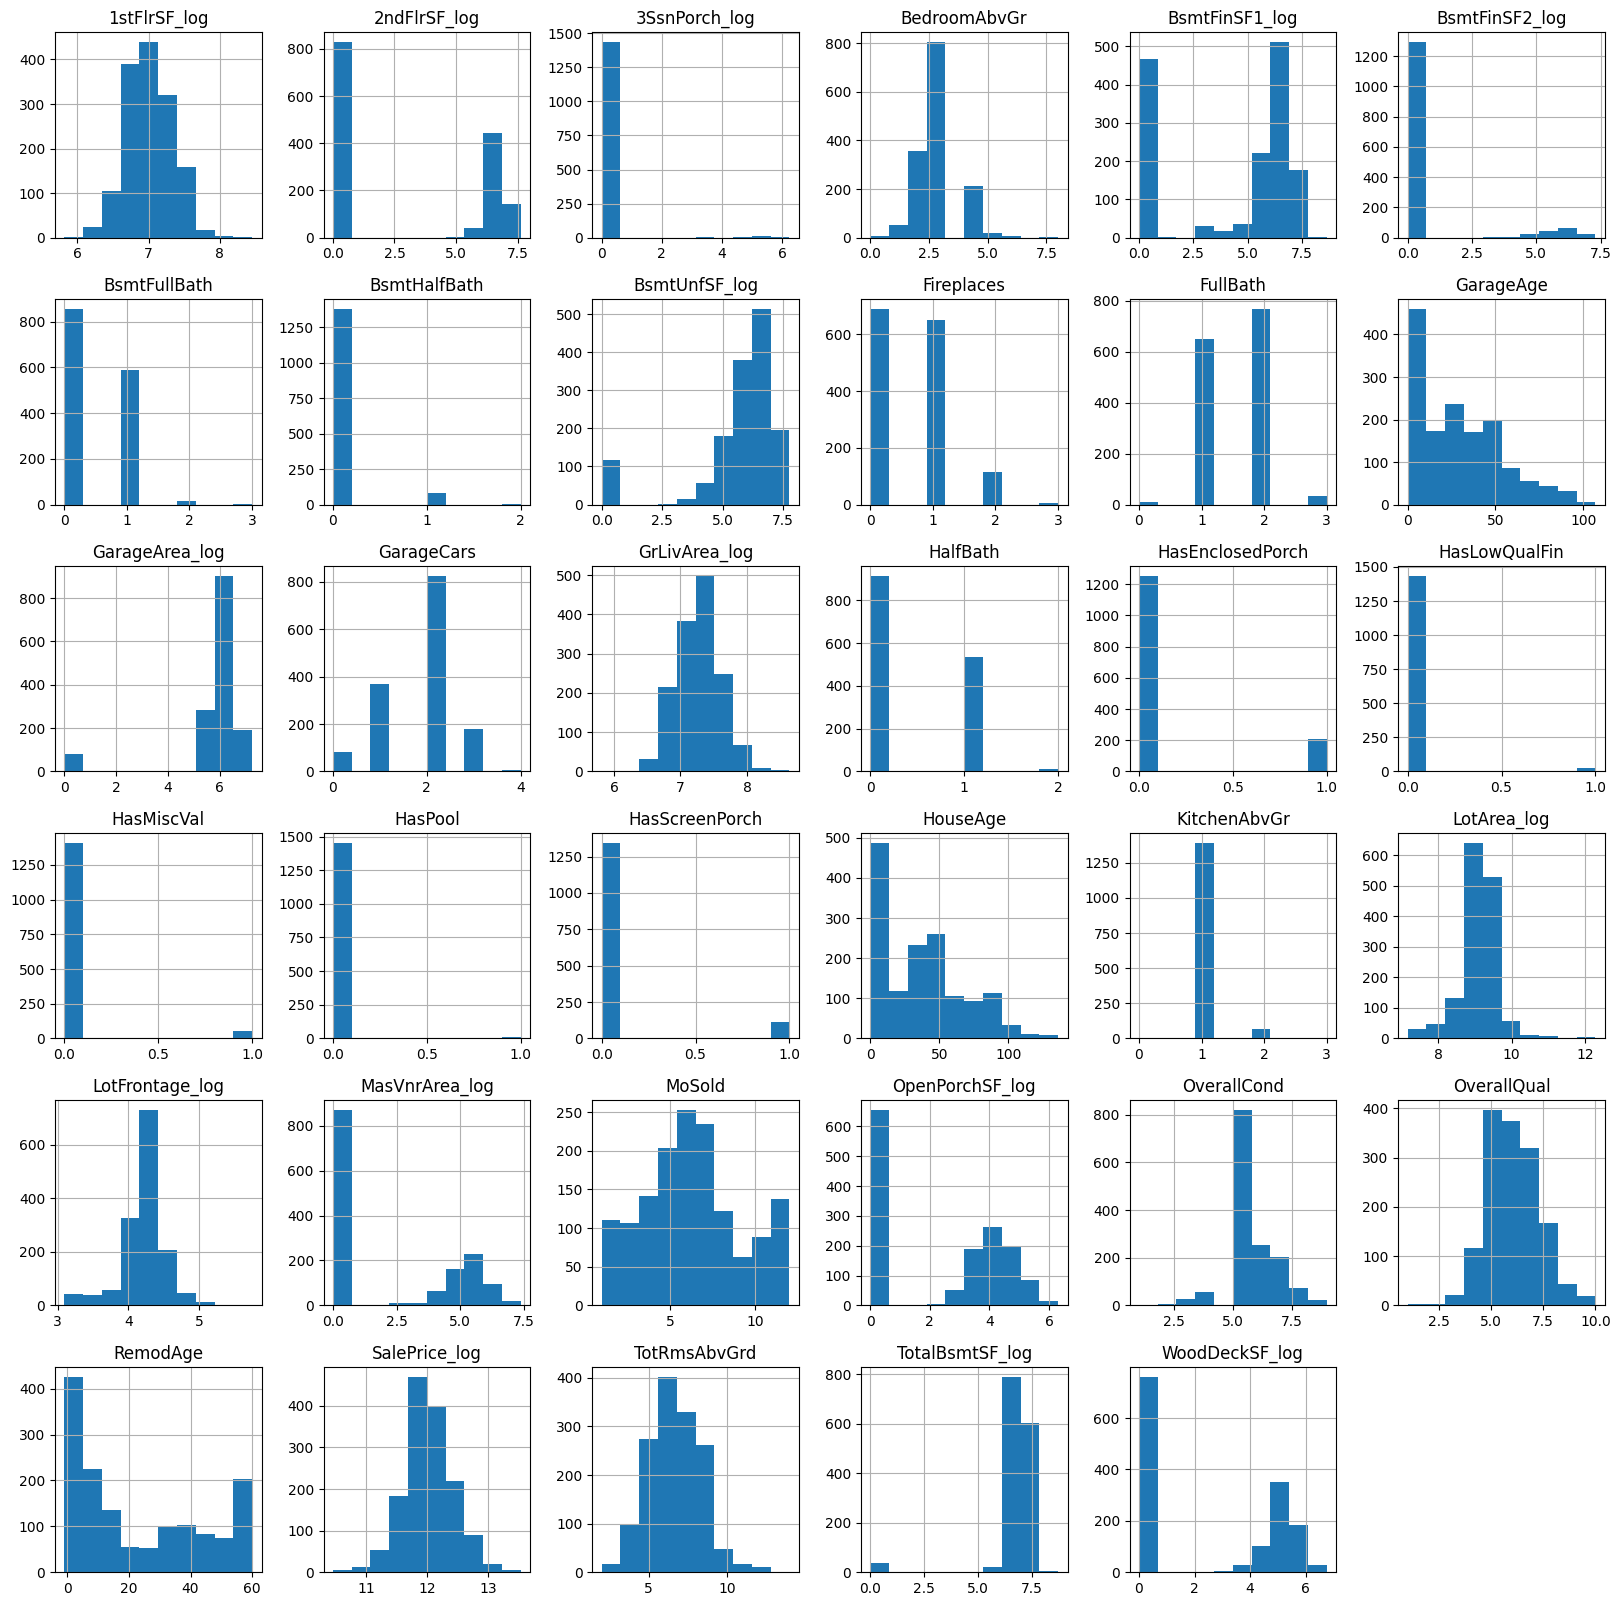

In [18]:
raw_train_df[numeric_features].hist(figsize=(20, 20))
plt.show()

In [13]:
# Log-transforming skewed numeric features to reduce skewness and improve model performance
raw_train_df["LotFrontage_log"] = np.log1p(raw_train_df["LotFrontage"])
raw_test_df["LotFrontage_log"] = np.log1p(raw_test_df["LotFrontage"])

raw_train_df["LotArea_log"] = np.log1p(raw_train_df["LotArea"])
raw_test_df["LotArea_log"] = np.log1p(raw_test_df["LotArea"])

raw_train_df["1stFlrSF_log"] = np.log1p(raw_train_df["1stFlrSF"])
raw_test_df["1stFlrSF_log"] = np.log1p(raw_test_df["1stFlrSF"])

raw_train_df["2ndFlrSF_log"] = np.log1p(raw_train_df["2ndFlrSF"])
raw_test_df["2ndFlrSF_log"] = np.log1p(raw_test_df["2ndFlrSF"])

raw_train_df["3SsnPorch_log"] = np.log1p(raw_train_df["3SsnPorch"])
raw_test_df["3SsnPorch_log"] = np.log1p(raw_test_df["3SsnPorch"])

raw_train_df["BsmtFinSF1_log"] = np.log1p(raw_train_df["BsmtFinSF1"])
raw_test_df["BsmtFinSF1_log"] = np.log1p(raw_test_df["BsmtFinSF1"])

raw_train_df["BsmtFinSF2_log"] = np.log1p(raw_train_df["BsmtFinSF2"])
raw_test_df["BsmtFinSF2_log"] = np.log1p(raw_test_df["BsmtFinSF2"])

raw_train_df["BsmtUnfSF_log"] = np.log1p(raw_train_df["BsmtUnfSF"])
raw_test_df["BsmtUnfSF_log"] = np.log1p(raw_test_df["BsmtUnfSF"])

raw_train_df["GarageArea_log"] = np.log1p(raw_train_df["GarageArea"])
raw_test_df["GarageArea_log"] = np.log1p(raw_test_df["GarageArea"])

raw_train_df["GrLivArea_log"] = np.log1p(raw_train_df["GrLivArea"])
raw_test_df["GrLivArea_log"] = np.log1p(raw_test_df["GrLivArea"])

raw_train_df["MasVnrArea_log"] = np.log1p(raw_train_df["MasVnrArea"])
raw_test_df["MasVnrArea_log"] = np.log1p(raw_test_df["MasVnrArea"])

raw_train_df["OpenPorchSF_log"] = np.log1p(raw_train_df["OpenPorchSF"])
raw_test_df["OpenPorchSF_log"] = np.log1p(raw_test_df["OpenPorchSF"])

raw_train_df["TotalBsmtSF_log"] = np.log1p(raw_train_df["TotalBsmtSF"])
raw_test_df["TotalBsmtSF_log"] = np.log1p(raw_test_df["TotalBsmtSF"])

raw_train_df["WoodDeckSF_log"] = np.log1p(raw_train_df["WoodDeckSF"])
raw_test_df["WoodDeckSF_log"] = np.log1p(raw_test_df["WoodDeckSF"])

# Log-transforming the target variable SalePrice to reduce skewness and improve model performance
raw_train_df["SalePrice_log"] = np.log1p(raw_train_df["SalePrice"])

In [14]:
# Feature Engineering to create a new binary feature called "HasEnclosedPorch" that indicates whether a house has an enclosed porch or not
raw_train_df["HasEnclosedPorch"] = (raw_train_df["EnclosedPorch"] > 0).astype(int)
raw_test_df["HasEnclosedPorch"] = (raw_test_df["EnclosedPorch"] > 0).astype(int)

# Feature Engineering to create a new binary feature called "HasLowQualFin" that indicates whether a house has low quality finished area or not
raw_train_df["HasLowQualFin"] = (raw_train_df["LowQualFinSF"] > 0).astype(int)
raw_test_df["HasLowQualFin"] = (raw_test_df["LowQualFinSF"] > 0).astype(int)

# Feature Engineering to create a new binary feature called "HasMiscVal" that indicates whether a house has miscellaneous value or not
raw_train_df["HasMiscVal"] = (raw_train_df["MiscVal"] > 0).astype(int)
raw_test_df["HasMiscVal"] = (raw_test_df["MiscVal"] > 0).astype(int)

# Feature Engineering to create a new binary feature called "HasPool" that indicates whether a house has a pool or not
raw_train_df["HasPool"] = (raw_train_df["PoolArea"] > 0).astype(int)
raw_test_df["HasPool"] = (raw_test_df["PoolArea"] > 0).astype(int)

# Feature Engineering to create a new binary feature called "HasScreenPorch" that indicates whether a house has a screen porch or not
raw_train_df["HasScreenPorch"] = (raw_train_df["ScreenPorch"] > 0).astype(int)
raw_test_df["HasScreenPorch"] = (raw_test_df["ScreenPorch"] > 0).astype(int)

In [15]:
# Feature Engineering for YearBuilt and YrSold to create a new feature called "HouseAge" that represents the age of the house at the time of sale
raw_train_df["HouseAge"] = raw_train_df["YrSold"] - raw_train_df["YearBuilt"]
raw_test_df["HouseAge"] = raw_test_df["YrSold"] - raw_test_df["YearBuilt"]

# Feature Engineering for Remod Age to represent the number of years since the last remodeling at the time of sale
raw_train_df["RemodAge"] = raw_train_df["YrSold"] - raw_train_df["YearRemodAdd"]
raw_test_df["RemodAge"] = raw_test_df["YrSold"] - raw_test_df["YearRemodAdd"]

# Feature Engineering for Garage Age to represent the age of the garage at the time of sale
raw_train_df["GarageAge"] = raw_train_df["YrSold"] - raw_train_df["GarageYrBlt"]
raw_test_df["GarageAge"] = raw_test_df["YrSold"] - raw_test_df["GarageYrBlt"]

In [16]:
numeric_features = numeric_features.drop([
    "LotFrontage",
    "LotArea",
    "1stFlrSF",
    "2ndFlrSF",
    "3SsnPorch",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "EnclosedPorch",
    "GarageArea",
    "YearBuilt",
    "YearRemodAdd",
    "GarageYrBlt",
    "YrSold",
    "GrLivArea",
    "MasVnrArea",
    "OpenPorchSF",
    "LowQualFinSF",
    "MiscVal",
    "PoolArea",
    "TotalBsmtSF",
    "WoodDeckSF",
    "SalePrice",
    "ScreenPorch"
])

numeric_features = numeric_features.union([
    "LotFrontage_log",
    "LotArea_log",
    "1stFlrSF_log",
    "2ndFlrSF_log",
    "3SsnPorch_log",
    "BsmtFinSF1_log",
    "BsmtFinSF2_log",
    "BsmtUnfSF_log",
    "GarageArea_log",
    "GrLivArea_log",
    "MasVnrArea_log",
    "OpenPorchSF_log",
    "HouseAge",
    "RemodAge",
    "GarageAge",
    "HasEnclosedPorch",
    "HasLowQualFin",
    "HasMiscVal",
    "HasPool",
    "TotalBsmtSF_log",
    "WoodDeckSF_log",
    "SalePrice_log",
    "HasScreenPorch"
])

In [17]:
numeric_features

Index(['1stFlrSF_log', '2ndFlrSF_log', '3SsnPorch_log', 'BedroomAbvGr',
       'BsmtFinSF1_log', 'BsmtFinSF2_log', 'BsmtFullBath', 'BsmtHalfBath',
       'BsmtUnfSF_log', 'Fireplaces', 'FullBath', 'GarageAge',
       'GarageArea_log', 'GarageCars', 'GrLivArea_log', 'HalfBath',
       'HasEnclosedPorch', 'HasLowQualFin', 'HasMiscVal', 'HasPool',
       'HasScreenPorch', 'HouseAge', 'KitchenAbvGr', 'LotArea_log',
       'LotFrontage_log', 'MasVnrArea_log', 'MoSold', 'OpenPorchSF_log',
       'OverallCond', 'OverallQual', 'RemodAge', 'SalePrice_log',
       'TotRmsAbvGrd', 'TotalBsmtSF_log', 'WoodDeckSF_log'],
      dtype='object')

In [ ]:
# Baseline model that predicts the mean of the log-transformed SalePrice for all houses in the training set
y = raw_train_df["SalePrice_log"]
y_mean = y.mean()

mse = ((y - y_mean) ** 2).mean()
mse

np.float64(0.15945043447708565)

In [22]:
train_df = raw_train_df[numeric_features.union(categorical_features)]
test_df = raw_test_df[train_df.columns.drop("SalePrice_log")]

In [23]:
train_encoded = pd.get_dummies(
    train_df,
    drop_first=True
)

test_encoded = pd.get_dummies(
    test_df,
    drop_first=True
)

train_encoded, test_encoded = train_encoded.align(
    test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

In [44]:
X_train = train_encoded.drop(columns=["SalePrice_log"])
y_train = train_encoded["SalePrice_log"]

X_test = test_encoded.drop(columns=["SalePrice_log"], errors="ignore")

In [57]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor

models = {
    "LinearRegression": LinearRegression(),
    "Ridge (α=1.0)": Ridge(alpha=1.0),
    "Lasso (α=0.001)": Lasso(alpha=0.001, max_iter=10000),
    "ElasticNet (α=0.001, l1=0.5)": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():
    cv_mse = -cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )
    
    results.append({
        "Model": name,
        "CV MSE": cv_mse.mean(),
        "CV RMSE": np.sqrt(cv_mse.mean()),
        "Std (MSE)": cv_mse.std()
    })

In [59]:
results_df = pd.DataFrame(results).sort_values("CV MSE")

results_df.style.format({
    "CV MSE": "{:.6f}",
    "CV RMSE": "{:.4f}",
    "Std (MSE)": "{:.6f}"
})

,Model,CV MSE,CV RMSE,Std (MSE)
6,XGBoost,0.015747,0.1255,0.003085
3,"ElasticNet (α=0.001, l1=0.5)",0.015986,0.1264,0.003505
2,Lasso (α=0.001),0.016085,0.1268,0.003518
4,GradientBoosting,0.017118,0.1308,0.002253
1,Ridge (α=1.0),0.017616,0.1327,0.004059
5,RandomForest,0.020702,0.1439,0.002666
0,LinearRegression,0.025386,0.1593,0.009996


In [65]:
import numpy as np
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.model_selection import cross_val_score

# (optional but helps) ensure clean numeric matrix
X_mat = X_train.to_numpy(dtype=np.float64, copy=True)
y_vec = y_train.to_numpy(dtype=np.float64, copy=True)

enet_cv = ElasticNetCV(
    alphas=np.logspace(-4, -2, 60),
    l1_ratio=np.linspace(0.3, 0.7, 25),
    cv=5,
    max_iter=200000,
    tol=1e-3,
    n_jobs=-1,
    precompute=False   # ✅ key fix
)

enet_cv.fit(X_mat, y_vec)

print("Best alpha:", enet_cv.alpha_)
print("Best l1_ratio:", enet_cv.l1_ratio_)

enet_tuned = ElasticNet(
    alpha=enet_cv.alpha_,
    l1_ratio=enet_cv.l1_ratio_,
    max_iter=200000,
    tol=1e-3
)

enet_mse = -cross_val_score(
    enet_tuned,
    X_mat,
    y_vec,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
).mean()

print("Tuned ElasticNet MSE:", enet_mse)
print("Tuned ElasticNet RMSE:", np.sqrt(enet_mse))

Best alpha: 0.00103979841848149
Best l1_ratio: 0.5833333333333333
Tuned ElasticNet MSE: 0.015956126302309435
Tuned ElasticNet RMSE: 0.1263175613377231


In [64]:
# Hyperparameter tuning for XGBoost using xgb.cv to find the best number of boosting rounds with early stopping

import xgboost as xgb
import numpy as np

dtrain = xgb.DMatrix(X_train, label=y_train)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "max_depth": 3,              # try shallow first
    "eta": 0.03,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 1.0,
    "alpha": 0.0,
    "tree_method": "hist",
    "seed": 42
}

cv_results = xgb.cv(
    params=params,
    dtrain=dtrain,
    num_boost_round=10000,
    nfold=5,
    early_stopping_rounds=200,
    verbose_eval=200,
    shuffle=False
)

best_rmse = cv_results["test-rmse-mean"].min()
best_round = cv_results["test-rmse-mean"].idxmin()

print("Best CV RMSE:", best_rmse)

[0]	train-rmse:0.39092+0.00389	test-rmse:0.39121+0.01571
[200]	train-rmse:0.09620+0.00193	test-rmse:0.13250+0.00994
[400]	train-rmse:0.07760+0.00153	test-rmse:0.12636+0.01078
[600]	train-rmse:0.06664+0.00137	test-rmse:0.12518+0.01099
[800]	train-rmse:0.05814+0.00126	test-rmse:0.12460+0.01131
[1000]	train-rmse:0.05132+0.00115	test-rmse:0.12452+0.01131
[1200]	train-rmse:0.04556+0.00112	test-rmse:0.12447+0.01155
[1400]	train-rmse:0.04065+0.00105	test-rmse:0.12447+0.01155
[1413]	train-rmse:0.04036+0.00105	test-rmse:0.12447+0.01154
Best CV RMSE: 0.12444307081060738


In [66]:
test_encoded

,1stFlrSF_log,2ndFlrSF_log,3SsnPorch_log,BedroomAbvGr,BsmtFinSF1_log,BsmtFinSF2_log,BsmtFullBath,BsmtHalfBath,BsmtUnfSF_log,Fireplaces,...,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,Street_Pave,Utilities_NoSeWa
0,6.799056,0.000000,0.0,2,6.150603,4.976734,0.0,0.0,5.602119,0,...,False,False,False,False,False,False,False,True,True,0
1,7.192934,0.000000,0.0,3,6.828712,0.000000,0.0,0.0,6.008813,0,...,False,False,False,False,False,False,False,True,True,0
2,6.834109,6.553933,0.0,3,6.674561,0.000000,0.0,0.0,4.927254,1,...,False,False,False,False,False,False,False,True,True,0
3,6.831954,6.520621,0.0,3,6.401917,0.000000,0.0,0.0,5.783825,1,...,False,False,False,False,False,False,False,True,True,0
4,7.155396,0.000000,0.0,2,5.575949,0.000000,0.0,0.0,6.925595,0,...,False,False,False,False,False,False,False,True,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,6.304449,6.304449,0.0,3,0.000000,0.000000,0.0,0.0,6.304449,0,...,False,False,False,False,False,False,False,True,True,0
1455,6.304449,6.304449,0.0,3,5.533389,0.000000,0.0,0.0,5.686975,0,...,False,False,False,False,False,False,False,True,True,0
1456,7.110696,0.000000,0.0,4,7.110696,0.000000,1.0,0.0,0.000000,1,...,False,False,False,False,False,False,False,True,True,0
1457,6.878326,0.000000,0.0,3,5.823046,0.000000,0.0,1.0,6.356108,0,...,False,False,False,False,False,False,False,True,True,0


In [67]:
import numpy as np
import pandas as pd
from sklearn.linear_model import ElasticNet
import xgboost as xgb
from xgboost import XGBRegressor

# --- Make sure train/test feature columns match ---
# (if you've already ensured this earlier, it's still safe to keep)
X_test = test_encoded.reindex(columns=X_train.columns, fill_value=0)

# --- Tuned ElasticNet (use your tuned values here) ---
best_alpha = enet_cv.alpha_
best_l1_ratio = enet_cv.l1_ratio_

enet_final = ElasticNet(
    alpha=best_alpha,
    l1_ratio=best_l1_ratio,
    max_iter=200000,
    tol=1e-3
)
enet_final.fit(X_train, y_train)

# --- Tuned XGBoost (use your tuned values here) ---
# Use best_round from xgb.cv cell; set same core params you tuned with
xgb_final = XGBRegressor(
    n_estimators=best_round,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)
xgb_final.fit(X_train, y_train)

print("Fitted ElasticNet + XGBoost on full training data.")
print("ElasticNet alpha:", best_alpha, "l1_ratio:", best_l1_ratio)
print("XGBoost n_estimators:", best_round)

Fitted ElasticNet + XGBoost on full training data.
ElasticNet alpha: 0.00103979841848149 l1_ratio: 0.5833333333333333
XGBoost n_estimators: 1213


In [69]:
import numpy as np
import pandas as pd

# Predict in log-space
test_pred_log_enet = enet_final.predict(X_test)
test_pred_log_xgb  = xgb_final.predict(X_test)

# Optional: ensemble in log-space (often helps)
test_pred_log_ens = 0.5 * test_pred_log_enet + 0.5 * test_pred_log_xgb

# Inverse log transform back to SalePrice
# If you used np.log1p originally, use np.expm1 here.
test_pred_price_enet = np.expm1(test_pred_log_enet)
test_pred_price_xgb  = np.expm1(test_pred_log_xgb)
test_pred_price_ens  = np.expm1(test_pred_log_ens)

# Kaggle submission format
sub_enet = pd.DataFrame({"Id": ids, "SalePrice": test_pred_price_enet})
sub_xgb  = pd.DataFrame({"Id": ids, "SalePrice": test_pred_price_xgb})
sub_ens  = pd.DataFrame({"Id": ids, "SalePrice": test_pred_price_ens})

# (Recommended) avoid negative/zero prices due to numerical issues
for df in (sub_enet, sub_xgb, sub_ens):
    df["SalePrice"] = df["SalePrice"].clip(lower=1)

# Save
sub_enet.to_csv("submission_enet.csv", index=False)
sub_xgb.to_csv("submission_xgb.csv", index=False)
sub_ens.to_csv("submission_ensemble.csv", index=False)

sub_ens.head()

,Id,SalePrice
0,1461,117556.472926
1,1462,155433.298375
2,1463,184651.658586
3,1464,196245.153314
4,1465,193945.738283
